In [ ]:
import os
import csv
import time
import requests
import requests_cache
from dotenv import load_dotenv

# --- CACHING SETUP ---
# Creates a local cache database in your notebooks folder. 
# Reruns of the exact same query will load instantly from your hard drive!
requests_cache.install_cache('notebook_cache', backend='sqlite', expire_after=86400)

# 1. Load environment variables
load_dotenv(dotenv_path="../.env")

API_KEY = os.getenv("OPENALEX_API_KEY")
EMAIL = os.getenv("EMAIL")
BASE_URL = "https://api.openalex.org/works"

CONFIG_FILE = "../config/search_terms.csv"
OUTPUT_FILE = "../results/sandbox/pilot_hit_counts.csv"

context_terms = []
data_terms = []

# 2. Load the terms, capturing the search_field constraint
with open(CONFIG_FILE, mode='r', encoding='utf-8') as file:
    reader = csv.DictReader(file)
    for row in reader:
        if row['status'].strip().lower() in ['potential', 'active']:
            term = row['term'].strip()
            subgroup = row['subgroup'].strip()
            exclusions = row.get('exclusions', '').strip()
            
            # Default to expanded if blank, otherwise capture the constraint
            search_field = row.get('search_field', '').strip().lower()
            
            query_string = f"({term}) NOT ({exclusions})" if exclusions else f"{term}"
            
            term_data = {
                'subgroup': subgroup,
                'term': term,
                'query_string': query_string,
                'search_field': search_field
            }
            
            category = row['list'].strip().lower()
            if category == 'context':
                context_terms.append(term_data)
            elif category == 'data':
                data_terms.append(term_data)

print(f"Successfully loaded {len(context_terms)} context terms and {len(data_terms)} data terms.")

# 3. Define the OpenAlex query functions
def get_hit_count(filter_string):
    """Queries OpenAlex using a raw filter string."""
    params = {"filter": filter_string, "per-page": 1, "mailto": EMAIL}
    if API_KEY and API_KEY != "YOUR_API_KEY":
        params["api_key"] = API_KEY

    try:
        response = requests.get(BASE_URL, params=params)
        if response.status_code != 200:
            print(f"API Rejection [{response.status_code}]: {response.text}")
            return None
        response.raise_for_status() 
        return response.json().get("meta", {}).get("count", 0)
    except requests.exceptions.RequestException as e:
        print(f"Error querying OpenAlex: {e}")
        return None
    

title_restricted = [t['term'] for t in context_terms + data_terms if t['search_field'] == 'title']
print(f"Terms successfully restricted to title: {title_restricted}")

Successfully loaded 18 context terms and 50 data terms.
Terms successfully restricted to title: ['(ontology OR ontologies)', '("data management" OR "data manager" OR "data managers")', '"data sharing"']


In [4]:
# 1. Build strings dynamically based on search_field constraints
c_all = " OR ".join([f"({t['query_string']})" for t in context_terms])
c_abs = " OR ".join([f"({t['query_string']})" for t in context_terms if t['search_field'] != 'title'])

d_all = " OR ".join([f"({t['query_string']})" for t in data_terms])
d_abs = " OR ".join([f"({t['query_string']})" for t in data_terms if t['search_field'] != 'title'])

doc_types = "article|book-chapter|book|dissertation|preprint|proceedings-article"

print("Calculating true macro hit count respecting 'search_field' constraints...")
print("Fetching IDs to mathematically remove overlaps. This may take a minute.\n")

unique_macro_ids = set()

def fetch_ids_to_set(filter_string, target_set):
    cursor = "*"
    while cursor:
        params = {"filter": filter_string, "select": "id", "per-page": 200, "cursor": cursor, "mailto": EMAIL}
        if API_KEY and API_KEY != "YOUR_API_KEY": params["api_key"] = API_KEY
        try:
            response = requests.get(BASE_URL, params=params)
            if response.status_code != 200: break
            data = response.json()
            results = data.get("results", [])
            if not results: break
            for r in results: target_set.add(r["id"])
            cursor = data.get("meta", {}).get("next_cursor")
        except requests.exceptions.RequestException: break

# 2. Iterate through data terms to bypass the URL limit
for item in data_terms:
    print(f"Fetching IDs for: [{item['term']}]...", end=" ", flush=True)
    
    q_d_all = item['query_string']
    q_d_abs = item['query_string'] if item['search_field'] != 'title' else ""
    
    filters_to_run = []
    
    # Query A: Context in Title, Data in Abstract (Falls back to intersection if data term is title-restricted)
    if q_d_abs:
        filters_to_run.append(f"title.search:({c_all}),title_and_abstract.search:({q_d_abs}),type:{doc_types}")
    else:
        filters_to_run.append(f"title.search:({c_all}),title.search:({q_d_all}),type:{doc_types}")
        
    # Query B: Context in Abstract, Data in Title
    if c_abs:
        filters_to_run.append(f"title_and_abstract.search:({c_abs}),title.search:({q_d_all}),type:{doc_types}")

    # Deduplicate filter strings before running to save API calls
    for f in set(filters_to_run):
        fetch_ids_to_set(f, unique_macro_ids)
        
    print("Done.")

print("\n" + "-" * 55)
print(f"Total UNIQUE potential records in universe: {len(unique_macro_ids):,}")
print("-" * 55)

Calculating true macro hit count respecting 'search_field' constraints...
Fetching IDs to mathematically remove overlaps. This may take a minute.

Fetching IDs for: ["data commons"]... Done.
Fetching IDs for: ["knowledge commons"]... Done.
Fetching IDs for: [("data infrastructure" OR "data infrastructures")]... Done.
Fetching IDs for: [("information infrastructure" OR "information infrastructures")]... Done.
Fetching IDs for: [("knowledge infrastructure" OR "knowledge infrastructures")]... Done.
Fetching IDs for: [("data repository" OR "data repositories" OR "dataset repository" OR "dataset repositories")]... Done.
Fetching IDs for: [("data portal" OR "data portals")]... Done.
Fetching IDs for: [("community data system" OR "community data systems")]... Done.
Fetching IDs for: [("community infrastructure project" OR "community infrastructure projects")]... Done.
Fetching IDs for: [("data harmonization" OR "data harmonisation" OR "data harmonizability" OR "data harmonisability")]... Done

In [9]:
# 1. Build strings dynamically based on search_field constraints
c_all = " OR ".join([f"({t['query_string']})" for t in context_terms])
c_abs = " OR ".join([f"({t['query_string']})" for t in context_terms if t['search_field'] != 'title'])

d_all = " OR ".join([f"({t['query_string']})" for t in data_terms])
d_abs = " OR ".join([f"({t['query_string']})" for t in data_terms if t['search_field'] != 'title'])

doc_types = "article|book-chapter|book|dissertation|preprint|proceedings-article"

print("Calculating true macro hit count respecting 'search_field' constraints...")
print("Fetching IDs to mathematically remove overlaps. This may take a minute.\n")

unique_macro_ids = set()

def fetch_ids_to_set(filter_string, target_set):
    cursor = "*"
    while cursor:
        params = {"filter": filter_string, "select": "id", "per-page": 200, "cursor": cursor, "mailto": EMAIL}
        if API_KEY and API_KEY != "YOUR_API_KEY": params["api_key"] = API_KEY
        try:
            response = requests.get(BASE_URL, params=params)
            if response.status_code != 200: break
            data = response.json()
            results = data.get("results", [])
            if not results: break
            for r in results: target_set.add(r["id"])
            cursor = data.get("meta", {}).get("next_cursor")
        except requests.exceptions.RequestException: break

# 2. Iterate through data terms to bypass the URL limit
for item in data_terms:
    print(f"Fetching IDs for: [{item['term']}]...", end=" ", flush=True)
    
    q_d_all = item['query_string']
    q_d_abs = item['query_string'] if item['search_field'] != 'title' else ""
    
    filters_to_run = []
    
    # Query A: Context in Title, Data in Abstract (Falls back to intersection if data term is title-restricted)
    if q_d_abs:
        filters_to_run.append(f"title.search:({c_all}),title_and_abstract.search:({q_d_abs}),type:{doc_types}")
    else:
        filters_to_run.append(f"title.search:({c_all}),title.search:({q_d_all}),type:{doc_types}")
        
    # Query B: Context in Abstract, Data in Title
    if c_abs:
        filters_to_run.append(f"title_and_abstract.search:({c_abs}),title.search:({q_d_all}),type:{doc_types}")

    # Deduplicate filter strings before running to save API calls
    for f in set(filters_to_run):
        fetch_ids_to_set(f, unique_macro_ids)
        
    print("Done.")

print("\n" + "-" * 55)
print(f"Total UNIQUE potential records in universe: {len(unique_macro_ids):,}")
print("-" * 55)

Starting Phase 1: (ANY Context) AND (Specific Data Term)
Querying Data Term: "data commons"... Hits: 26
Querying Data Term: "knowledge commons"... Hits: 19
Querying Data Term: ("data infrastructure" OR "data infrastructures")... Hits: 269
Querying Data Term: ("information infrastructure" OR "information infrastructures")... Hits: 165
Querying Data Term: ("knowledge infrastructure" OR "knowledge infrastructures")... Hits: 69
Querying Data Term: ("data repository" OR "data repositories" OR "dataset repository" OR "dataset repositories")... Hits: 139
Querying Data Term: ("data portal" OR "data portals")... Hits: 43
Querying Data Term: ("community data system" OR "community data systems")... Hits: 1
Querying Data Term: ("community infrastructure project" OR "community infrastructure projects")... Hits: 1
Querying Data Term: ("data harmonization" OR "data harmonisation" OR "data harmonizability" OR "data harmonisability")... Hits: 21
Querying Data Term: ("construct harmonization" OR "constr

<>:28: SyntaxWarning: invalid escape sequence '\w'
<>:28: SyntaxWarning: invalid escape sequence '\w'
C:\Users\njsgi\AppData\Local\Temp\ipykernel_9636\4101702364.py:28: SyntaxWarning: invalid escape sequence '\w'
  regex_pattern = raw_term.replace('"', '').replace(' OR ', '|').replace('*', '\w*')


Loading datasets...
Parsed 68 active search terms.
Building keyword and search term matrices (this takes ~5 seconds)...


C:\Users\njsgi\AppData\Local\Temp\ipykernel_9636\4101702364.py:47: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  term_dict = {label: df_records['text'].str.contains(pattern, regex=True).astype(int) for label, pattern in search_terms.items()}
C:\Users\njsgi\AppData\Local\Temp\ipykernel_9636\4101702364.py:47: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  term_dict = {label: df_records['text'].str.contains(pattern, regex=True).astype(int) for label, pattern in search_terms.items()}
C:\Users\njsgi\AppData\Local\Temp\ipykernel_9636\4101702364.py:47: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  term_dict = {label: df_records['text'].str.contains(pattern, regex=True).astype(int) for label, pattern in search_terms.items()}
C:\User

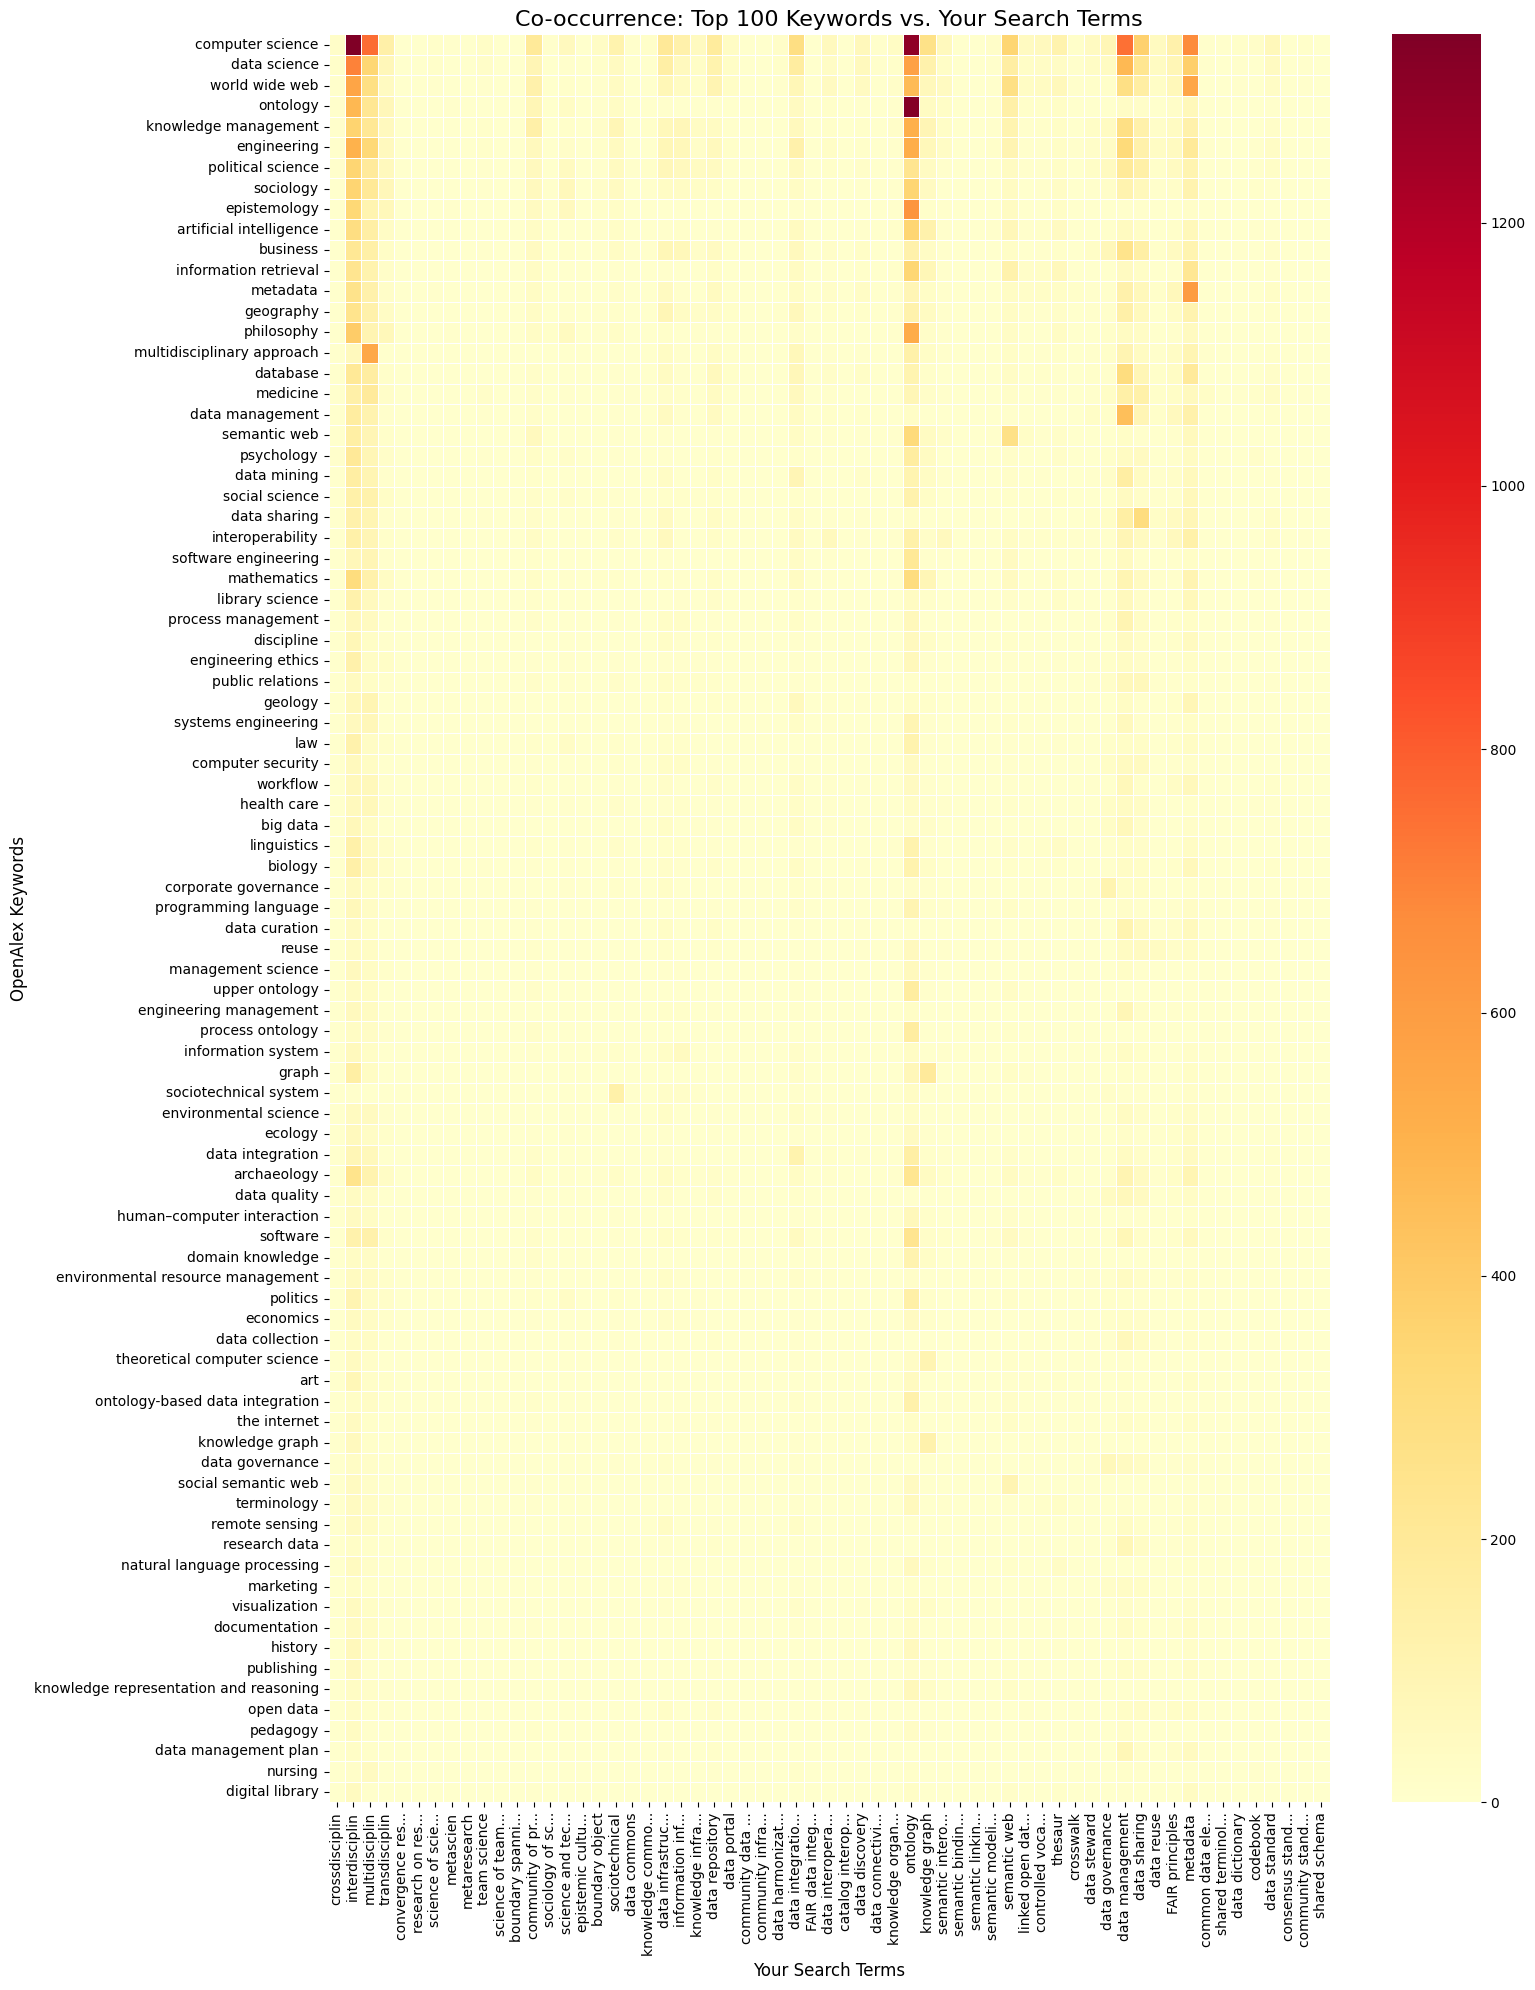


--- SUSPICIOUS OVERLAPS (Potential Exclusions) ---
Which of your search terms are pulling in these potentially out-of-scope topics?

Keyword: [ARTIFICIAL INTELLIGENCE] co-occurs mostly with:
   -> ontology: 350 papers
   -> interdisciplin: 289 papers
   -> multidisciplin: 148 papers
----------------------------------------
Keyword: [DATA MINING] co-occurs mostly with:
   -> interdisciplin: 158 papers
   -> data management: 158 papers
   -> ontology: 107 papers
----------------------------------------


In [6]:
import pandas as pd
import numpy as np
import re
import csv
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. LOAD DATA ---
print("Loading datasets...")
df_records = pd.read_csv("../data/03_processed/openalex_records_deduped.csv")
# Combine title and abstract for text searching
df_records['text'] = (df_records['title'].fillna('') + " " + df_records['abstract'].fillna('')).str.lower()

# Extract top 100 keywords
keywords_series = df_records['keywords'].dropna().str.lower().str.split('; ').explode().str.strip()
keywords_series = keywords_series[keywords_series != '']
top_100_kws = keywords_series.value_counts().head(100).index.tolist()

# --- 2. LOAD & PARSE SEARCH TERMS ---
search_terms = {}
with open("../config/search_terms.csv", mode='r', encoding='utf-8') as f:
    reader = csv.DictReader(f)
    for row in reader:
        if row['status'].strip().lower() in ['potential', 'active']:
            raw_term = row['term'].strip()
            # Convert boolean/wildcard to regex: 
            # 1. Remove quotes 2. Replace OR with | 3. Replace * with \w*
            regex_pattern = raw_term.replace('"', '').replace(' OR ', '|').replace('*', '\w*')
            # Add word boundaries so we don't accidentally match substrings
            regex_pattern = rf"\b{regex_pattern}\b"
            
            # Shorten the label for the chart (grab the first word/concept)
            label = re.sub(r'[^a-zA-Z\s]', '', raw_term.split(' OR ')[0]).strip()
            if len(label) > 15: label = label[:15] + "..."
            search_terms[label] = regex_pattern.lower()

print(f"Parsed {len(search_terms)} active search terms.")

# --- 3. BUILD MATRICES ---
print("Building keyword and search term matrices (this takes ~5 seconds)...")

# Matrix A: Does record have Keyword X? (n_records x 100)
kw_dict = {kw: df_records['keywords'].fillna('').str.lower().str.contains(rf"\b{re.escape(kw)}\b", regex=True).astype(int) for kw in top_100_kws}
df_kw = pd.DataFrame(kw_dict)

# Matrix B: Does record have Search Term Y? (n_records x n_terms)
term_dict = {label: df_records['text'].str.contains(pattern, regex=True).astype(int) for label, pattern in search_terms.items()}
df_terms = pd.DataFrame(term_dict)

# Calculate Co-occurrence via Dot Product
co_occurrence_matrix = df_kw.T.dot(df_terms)

# --- 4. VISUALIZATION & ANALYSIS ---
# Filter out empty rows/cols to keep the chart clean
co_occurrence_matrix = co_occurrence_matrix.loc[(co_occurrence_matrix.sum(axis=1) > 0), (co_occurrence_matrix.sum(axis=0) > 0)]

plt.figure(figsize=(16, 20))
sns.heatmap(co_occurrence_matrix, cmap="YlOrRd", linewidths=.5)
plt.title("Co-occurrence: Top 100 Keywords vs. Your Search Terms", fontsize=16)
plt.xlabel("Your Search Terms", fontsize=12)
plt.ylabel("OpenAlex Keywords", fontsize=12)
plt.tight_layout()
plt.show()

# --- 5. EXTRACT THE HIGHEST NOISE SUSPECTS ---
# Let's look for terms commonly associated with out-of-scope fields
suspicious_keywords = ['artificial intelligence', 'machine learning', 'data mining', 'computer vision', 'genomics', 'covid-19', 'algorithm']
found_suspects = [k for k in suspicious_keywords if k in co_occurrence_matrix.index]

if found_suspects:
    print("\n--- SUSPICIOUS OVERLAPS (Potential Exclusions) ---")
    print("Which of your search terms are pulling in these potentially out-of-scope topics?\n")
    
    for kw in found_suspects:
        print(f"Keyword: [{kw.upper()}] co-occurs mostly with:")
        top_pullers = co_occurrence_matrix.loc[kw].sort_values(ascending=False).head(3)
        for term, count in top_pullers.items():
            if count > 0:
                print(f"   -> {term}: {count} papers")
        print("-" * 40)

Loading data for trend analysis...


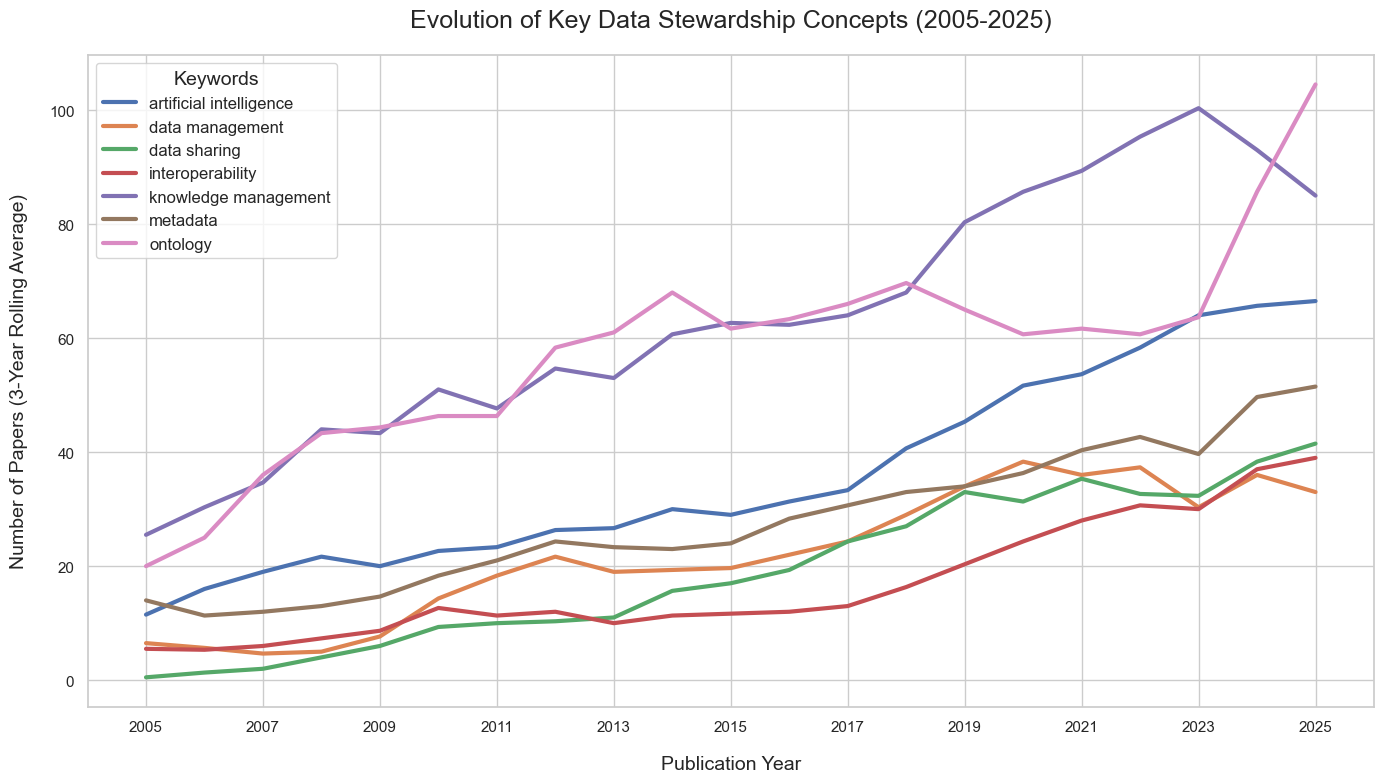

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. LOAD & PREP DATA ---
print("Loading data for trend analysis...")
df = pd.read_csv("../data/03_processed/openalex_records_deduped.csv")

# Drop rows missing years or keywords, and ensure years are numbers
df = df.dropna(subset=['publication_year', 'keywords'])
df['publication_year'] = pd.to_numeric(df['publication_year'], errors='coerce')

# Filter to a logical modern window (e.g., 2005 to present)
df = df[(df['publication_year'] >= 2005) & (df['publication_year'] <= 2025)]

# Explode the keywords
df['keywords'] = df['keywords'].astype(str).str.lower().str.split('; ')
exploded = df.explode('keywords')
exploded['keywords'] = exploded['keywords'].str.strip()

# --- 2. DEFINE TARGET TERMS TO TRACK ---
target_terms = [
    'fair principles',
    'metadata', 
    'ontology', 
    'data sharing', 
    'interoperability', 
    'data management', 
    'knowledge management',
    'linked open data',
    'artificial intelligence'
]

# Filter our exploded dataset to just these terms
trend_data = exploded[exploded['keywords'].isin(target_terms)]

# Pivot the data to get Years on the X-axis and Keywords as columns
pivot_df = trend_data.groupby(['publication_year', 'keywords']).size().unstack(fill_value=0)

# --- APPLY SMOOTHING ---
# A window of 3, centered, averages the target year with +/- 1 year around it.
# min_periods=1 ensures we don't drop the very first (2005) and last (2025) years.
pivot_smoothed = pivot_df.rolling(window=3, center=True, min_periods=1).mean()

# --- 3. VISUALIZE ---
plt.figure(figsize=(14, 8))

# Set a clean seaborn style and plot the SMOOTHED data
sns.set_theme(style="whitegrid")
sns.lineplot(data=pivot_smoothed, dashes=False, linewidth=3)

plt.title("Evolution of Key Data Stewardship Concepts (2005-2025)", fontsize=18, pad=20)
plt.xlabel("Publication Year", fontsize=14, labelpad=15)
plt.ylabel("Number of Papers (3-Year Rolling Average)", fontsize=14, labelpad=15)
plt.xticks(range(2005, 2026, 2)) # Show every 2 years for clean X-axis

# Make the legend look nice
plt.legend(title="Keywords", title_fontsize='14', fontsize='12', loc='upper left')

plt.tight_layout()
plt.show()